In [71]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [72]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [73]:
file_path="/Users/DELL/Downloads/titanic.csv"

In [74]:
df=pd.read_csv(file_path)

In [75]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [76]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [77]:
df.shape

(891, 12)

In [78]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [79]:
df.duplicated().value_counts()

False    891
Name: count, dtype: int64

In [80]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [81]:
missing=df.isnull().sum()

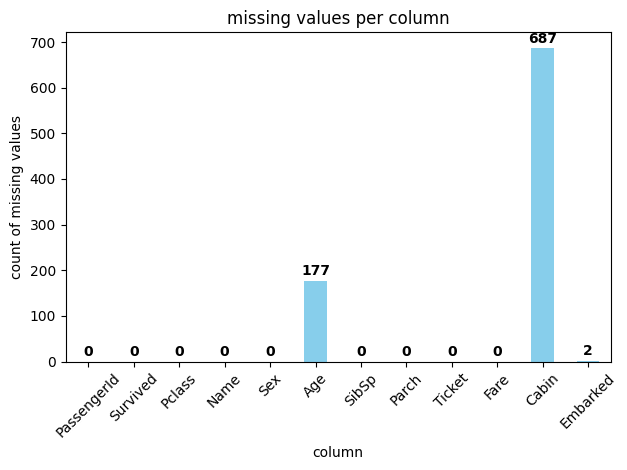

In [82]:
ax=missing.plot(kind='bar',color='skyblue')
plt.title('missing values per column')
plt.ylabel('count of missing values')
plt.xlabel('column')
plt.xticks(rotation=45)
for index,value in enumerate(missing):
    plt.text(index,value+5,str(value),ha='center',va='bottom',fontsize=10,fontweight='bold')
plt.tight_layout()
plt.show()

In [83]:
df=df.drop(columns=['Cabin'])
df['Age']=df['Age'].fillna(df['Age'].median())
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [84]:
survival_counts=df['Survived'].value_counts()
print("Survival counts:\n",survival_counts)

Survival counts:
 Survived
0    549
1    342
Name: count, dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_11600\2536952475.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived',data=df,palette='pastel')


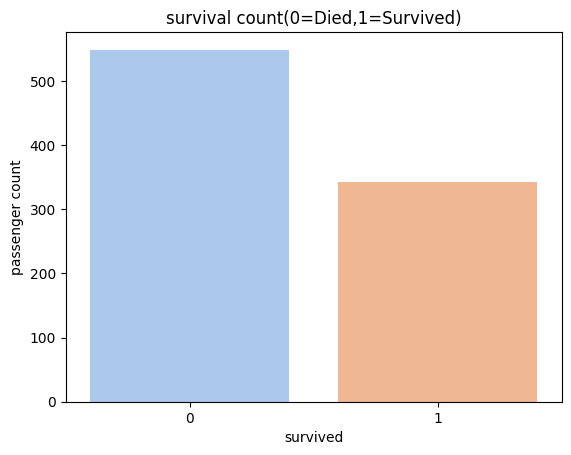

In [85]:
sns.countplot(x='Survived',data=df,palette='pastel')
plt.title('survival count(0=Died,1=Survived)')
plt.xlabel('survived')
plt.ylabel('passenger count')
plt.show()

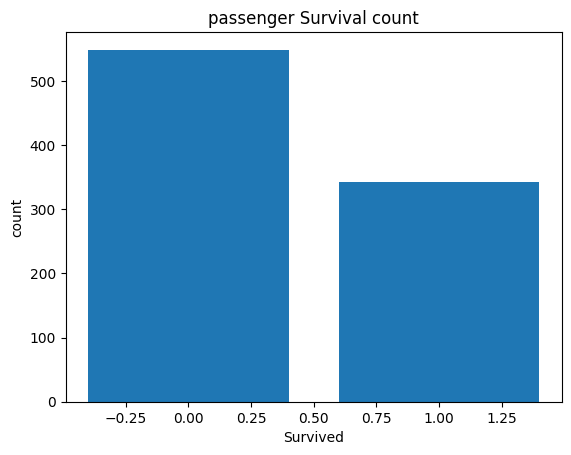

In [86]:
counts=df['Survived'].value_counts()
plt.bar(counts.index,counts.values)
plt.xlabel("Survived")
plt.ylabel("count")
plt.title("passenger Survival count")
plt.show()

In [87]:
gender_counts=df['Sex'].value_counts()
print("\nGender Counts:\n",gender_counts)


Gender Counts:
 Sex
male      577
female    314
Name: count, dtype: int64


In [88]:
survival_by_gender=df.groupby(['Sex','Survived']).size()
print("\nSurvival by gender:\n",survival_by_gender)



Survival by gender:
 Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
dtype: int64


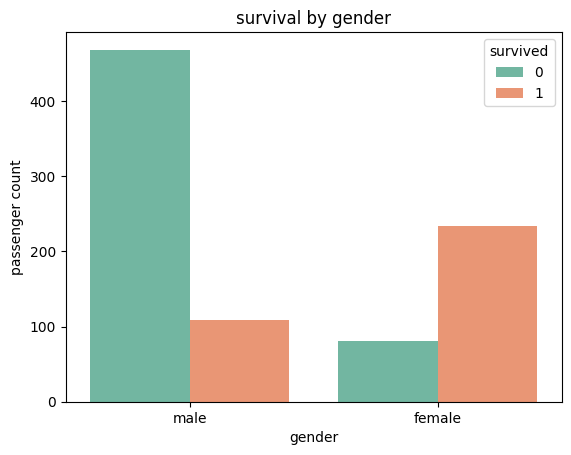

In [89]:
sns.countplot(x='Sex',hue='Survived',data=df,palette='Set2')
plt.title('survival by gender')
plt.xlabel('gender')
plt.ylabel('passenger count')
plt.legend(title='survived')
plt.show()


In [99]:
pclass_counts=df['Pclass'].value_counts()
print(pclass_counts)


Pclass
3    491
1    216
2    184
Name: count, dtype: int64


In [97]:
labels=['Class 3(Lower)','Class 1(Upper)','Class 2(Middle)']


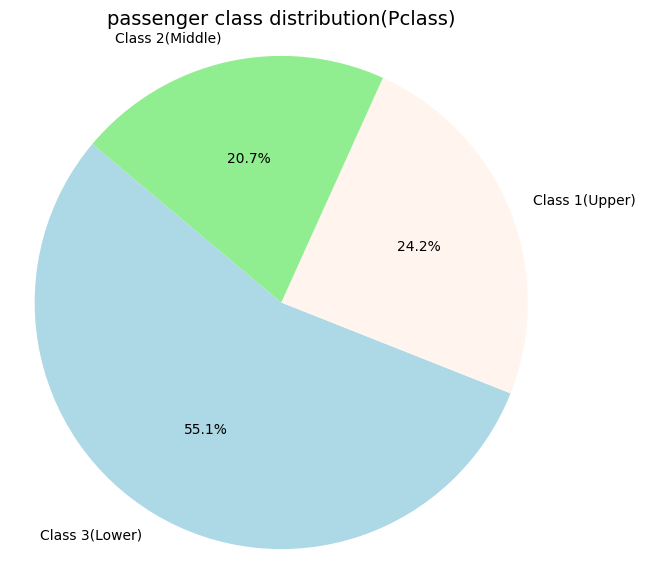

In [105]:
plt.figure(figsize=(7,7))
plt.pie(pclass_counts,labels=labels,autopct='%1.1f%%',startangle=140,colors=['lightblue','seashell','lightgreen'])
plt.title('passenger class distribution(Pclass)',fontsize=14)
plt.axis('equal')
plt.show()

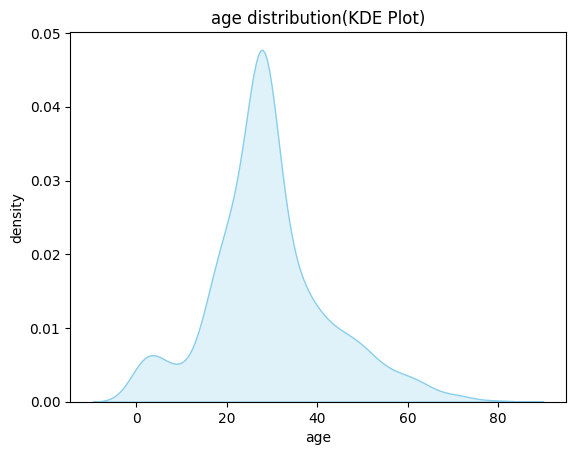

In [106]:
sns.kdeplot(df['Age'],fill=True,color='skyblue')
plt.title('age distribution(KDE Plot)')
plt.xlabel('age')
plt.ylabel('density')
plt.show()

<Axes: xlabel='Age', ylabel='Count'>

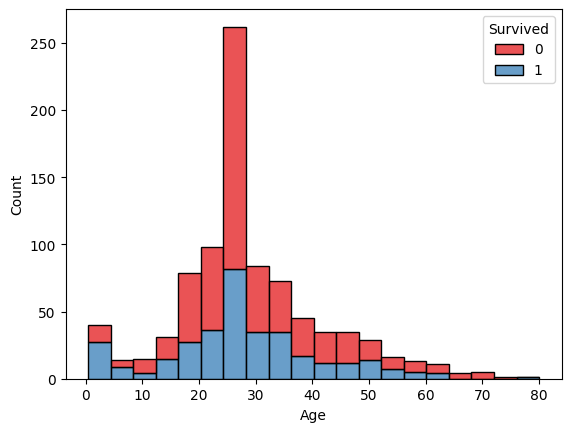

In [107]:
sns.histplot(data=df,x='Age',hue='Survived',multiple='stack',bins=20,palette='Set1')
             
             

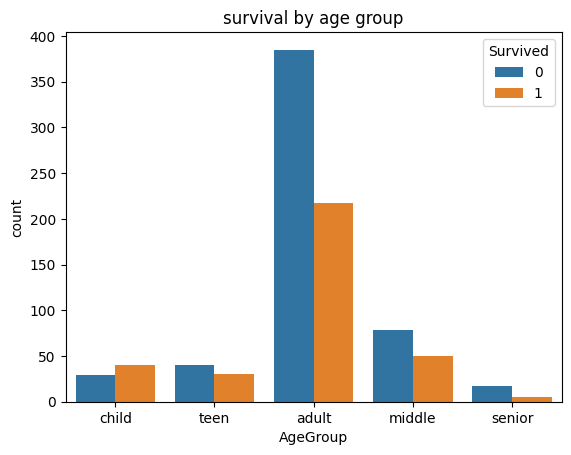

In [111]:
df['AgeGroup']=pd.cut(df['Age'],bins=[0,12,18,40,60,100],labels=['child','teen','adult','middle','senior'])
sns.countplot(x='AgeGroup',hue='Survived',data=df)
plt.title('survival by age group')
plt.show()
